In [1]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Loading the csv in a df
- checking if there is any missing value.
- checking for empty row or coloumns
- identifying the column names
- identifying the shape and structure of the dataset

In [3]:
df = pd.read_csv("Boston.csv")
df.head()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


Removing unnecessary columns, particularly `Unnamed: 0`

In [10]:
dfnew = df.drop(columns="Unnamed: 0")

### Questiuon 1:
**"Report the class of the data set. How many rows and columns are in this data set? What do the rows and columns represent?"**

In [18]:
print("Shape of the new dataset is",dfnew.shape)
print()
dfnew.info()

Shape of the new dataset is (506, 14)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  black    506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


Class of the dataset

In [19]:
type(dfnew)

pandas.core.frame.DataFrame

#### Row and Column description
- There arr 506 rows, each row represents one Boston suburb
- There are 14 columns, each column represents one measured variable

### Question 2:
**"Create a smaller data set with the variables median value of owner-occupied
homes, per capita crime rate, nitrogen oxides concentration, proportion of
blacks and percentage of lower status of the population. Choosing median
value of owner occupied homes as the response and the rest as the predictors,
make scatter plots of the response versus each predictor. Present
the scatter plots in different panels of the same graph. Comment on your
findings."**

In [24]:
colms = ["medv", "crim", "nox", "black", "lstat"]
small_df_new = dfnew[colms]

print("Shape of the smaller dataset created is ", small_df_new.shape)
print()
small_df_new.head()

Shape of the smaller dataset created is  (506, 5)



,medv,crim,nox,black,lstat
0,24.0,0.00632,0.538,396.90,4.98
1,21.6,0.02731,0.469,396.90,9.14
2,34.7,0.02729,0.469,392.83,4.03
3,33.4,0.03237,0.458,394.63,2.94
4,36.2,0.06905,0.458,396.90,5.33


Scatter plots:

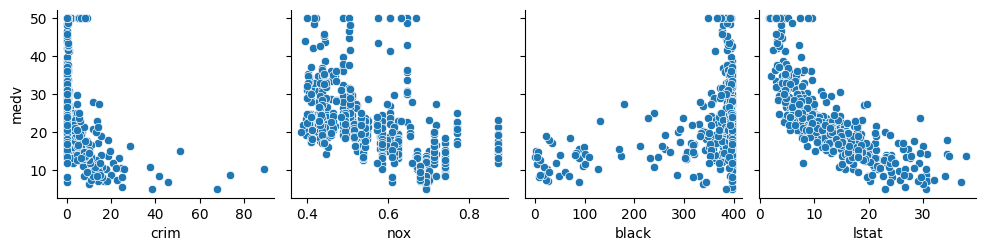

In [26]:
sns.pairplot(small_df_new, y_vars="medv", x_vars=["crim", "nox", "black", "lstat"])
plt.show()



#### Medv vs Crim
- There is a strong negative relationship between crime rate and median house value. Suburbs with higher crime rates tend to have significantly lower housing prices, and high-value houses are concentrated in low-crime areas.
#### Medv vs Nox
- Median house value tends to decrease as nitrogen oxide concentration increases, indicating that more polluted areas generally have lower property values, although the relationship is not perfectly linear.
#### Medv vs proportion of black
- The relationship between MEDV and proportion of black is nonlinear due to the transformed nature of the variable. However, higher house values tend to occur in regions with higher values of this variable, while lower values of BLACK are associated with lower MEDV.
#### Medv vs istat
- There is a very strong negative and nonlinear relationship between LSTAT and MEDV. As the percentage of lower-status population increases, median house values decrease sharply, making LSTAT one of the strongest predictors of housing prices.

### Question 3
**"Which suburb of Boston has lowest median value of owner-occupied homes?
What are the values of the other predictors mentioned in (2), for that
suburb. How do these values compare to the overall ranges for those predictors?
Comment on your findings. Hint: Mention which percentile these
values belong to."**

In [30]:
print(small_df_new["medv"].idxmin())

398


In [31]:
print(small_df_new["medv"].min())

5.0


The 398th suburb has the lowest median value of owner-occupied homes. To be eaxct 5.

In [32]:
minimum_medv  = small_df_new.loc[small_df_new["medv"].idxmin()]
minimum_medv

medv       5.0000
crim      38.3518
nox        0.6930
black    396.9000
lstat     30.5900
Name: 398, dtype: float64

Computing percentiles for each predictors

In [33]:
small_df_new[["crim", "nox", "black", "lstat"]].rank(pct=True).loc[small_df_new["medv"].idxmin()]


crim     0.988142
nox      0.844862
black    0.881423
lstat    0.978261
Name: 398, dtype: float64

In [36]:
dfnew[["crim", "nox", "black", "lstat"]].describe()


,crim,nox,black,lstat
count,506.000000,506.000000,506.000000,506.000000
mean,3.613524,0.554695,356.674032,12.653063
std,8.601545,0.115878,91.294864,7.141062
min,0.006320,0.385000,0.320000,1.730000
25%,0.082045,0.449000,375.377500,6.950000
50%,0.256510,0.538000,391.440000,11.360000
75%,3.677083,0.624000,396.225000,16.955000
max,88.976200,0.871000,396.900000,37.970000


#### Description of Predictor values for the lowest median value of owner-occupied homes:
-
-
-
-

### Question 4:
**"Does any suburb of Boston stand out for having notably high crime rates,
tax rates, or pupil–teacher ratios? Hint: Use a boxplot to detect any
outliers. If so, identify the suburbs that show the outlier values."**

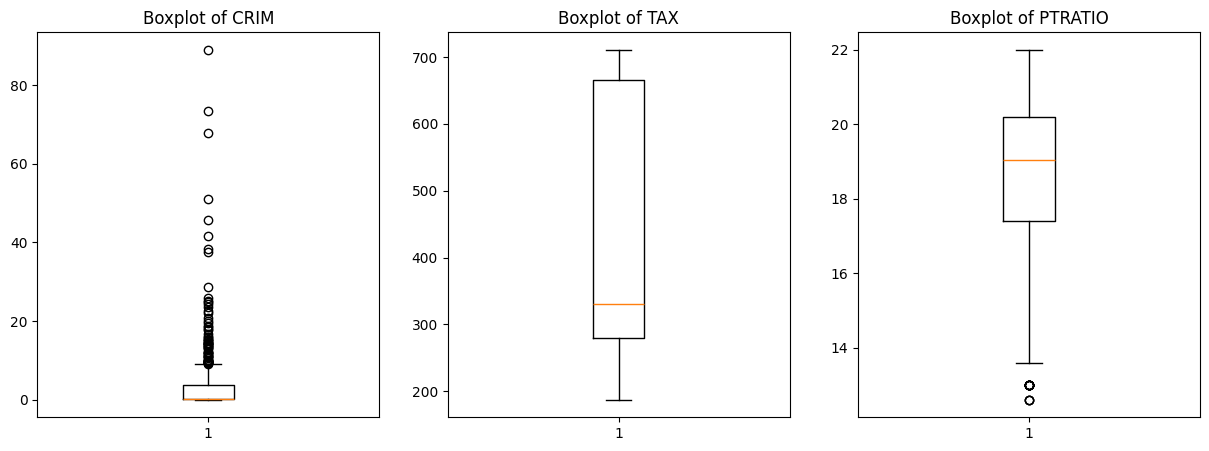

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# CRIM
axes[0].boxplot(df["crim"])
axes[0].set_title("Boxplot of CRIM")

# TAX
axes[1].boxplot(df["tax"])
axes[1].set_title("Boxplot of TAX")

# PTRATIO
axes[2].boxplot(df["ptratio"])
axes[2].set_title("Boxplot of PTRATIO")

plt.show()


Identifying outliers

In [43]:
def find_outliers(col):
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    
    return col[(col > upper)|(col < lower)]


In [44]:
crim_outliers = find_outliers(dfnew["crim"])
tax_outliers = find_outliers(dfnew["tax"])
ptratio_outliers = find_outliers(dfnew["ptratio"])


Identifying the suburbs containing the outliers

In [46]:
dfnew.loc[crim_outliers.index]



,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
367,13.5222,0.0,18.1,0,0.631,3.863,100.0,1.5106,24,666,20.2,131.42,13.33,23.1
371,9.2323,0.0,18.1,0,0.631,6.216,100.0,1.1691,24,666,20.2,366.15,9.53,50.0
373,11.1081,0.0,18.1,0,0.668,4.906,100.0,1.1742,24,666,20.2,396.90,34.77,13.8
374,18.4982,0.0,18.1,0,0.668,4.138,100.0,1.1370,24,666,20.2,396.90,37.97,13.8
375,19.6091,0.0,18.1,0,0.671,7.313,97.9,1.3163,24,666,20.2,396.90,13.44,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
468,15.5757,0.0,18.1,0,0.580,5.926,71.0,2.9084,24,666,20.2,368.74,18.13,19.1
469,13.0751,0.0,18.1,0,0.580,5.713,56.7,2.8237,24,666,20.2,396.90,14.76,20.1
477,15.0234,0.0,18.1,0,0.614,5.304,97.3,2.1007,24,666,20.2,349.48,24.91,12.0
478,10.2330,0.0,18.1,0,0.614,6.185,96.7,2.1705,24,666,20.2,379.70,18.03,14.6


In [47]:
dfnew.loc[tax_outliers.index]


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv


In [48]:
dfnew.loc[ptratio_outliers.index]

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
196,0.04011,80.0,1.52,0,0.404,7.287,34.1,7.3090,2,329,12.6,396.90,4.08,33.3
197,0.04666,80.0,1.52,0,0.404,7.107,36.6,7.3090,2,329,12.6,354.31,8.61,30.3
198,0.03768,80.0,1.52,0,0.404,7.274,38.3,7.3090,2,329,12.6,392.20,6.62,34.6
257,0.61154,20.0,3.97,0,0.647,8.704,86.9,1.8010,5,264,13.0,389.70,5.12,50.0
258,0.66351,20.0,3.97,0,0.647,7.333,100.0,1.8946,5,264,13.0,383.29,7.79,36.0
259,0.65665,20.0,3.97,0,0.647,6.842,100.0,2.0107,5,264,13.0,391.93,6.90,30.1
260,0.54011,20.0,3.97,0,0.647,7.203,81.8,2.1121,5,264,13.0,392.80,9.59,33.8
261,0.53412,20.0,3.97,0,0.647,7.520,89.4,2.1398,5,264,13.0,388.37,7.26,43.1
262,0.52014,20.0,3.97,0,0.647,8.398,91.5,2.2885,5,264,13.0,386.86,5.91,48.8
263,0.82526,20.0,3.97,0,0.647,7.327,94.5,2.0788,5,264,13.0,393.42,11.25,31.0
